# 🏎️ F1 Pit Stop | OOF Blend — LightGBM + RealMLP
### Playground Series S6E5

Blends OOF predictions from:
- `oof_lgbm_fe.csv` — LightGBM with full FE + weighted sample training
- `oof_realmlp_fe.csv` — RealMLP_TD with full FE

Finds the optimal blend weight via OOF AUC, then applies it to test predictions.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## 2. Load OOFs + Ground Truth

In [2]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/train.csv')
y     = train['PitNextLap'].copy()

# ── OOF predictions ──────────────────────────────────────────────────────────
# Update these paths if your OOF files are saved elsewhere
lgbm_oof    = pd.read_csv('/kaggle/input/datasets/adwaittagalpallewar/s6e5-oofs-for-blend/oof_lgbm_fe.csv').set_index('id')['PitNextLap']
realmlp_oof = pd.read_csv('/kaggle/input/datasets/adwaittagalpallewar/s6e5-oofs-for-blend/oof_realmlp_fe.csv').set_index('id')['PitNextLap']

# ── Test predictions ─────────────────────────────────────────────────────────
lgbm_sub    = pd.read_csv('/kaggle/input/datasets/adwaittagalpallewar/s6e5-oofs-for-blend/submission_lgbm_fe.csv').set_index('id')['PitNextLap']
realmlp_sub = pd.read_csv('/kaggle/input/datasets/adwaittagalpallewar/s6e5-oofs-for-blend/submission_realmlp_fe - lb-0.95259.csv').set_index('id')['PitNextLap']

# Align to train index order
ids          = train['id'].values
lgbm_oof     = lgbm_oof.loc[ids].values
realmlp_oof  = realmlp_oof.loc[ids].values
lgbm_sub     = lgbm_sub.values
realmlp_sub  = realmlp_sub.values

auc_lgbm    = roc_auc_score(y, lgbm_oof)
auc_realmlp = roc_auc_score(y, realmlp_oof)
print(f"LGBM    OOF AUC : {auc_lgbm:.6f}")
print(f"RealMLP OOF AUC : {auc_realmlp:.6f}")

LGBM    OOF AUC : 0.952511
RealMLP OOF AUC : 0.953105


## 3. Grid Search — Optimal Blend Weight

Sweep `w` from 0 → 1 where:
```
blend = w * lgbm_oof + (1 - w) * realmlp_oof
```
Pick the `w` that maximises OOF AUC.

In [3]:
weights  = np.linspace(0, 1, 201)   # 0.00, 0.005, 0.01, ... 1.00
aucs     = []

for w in weights:
    blend = w * lgbm_oof + (1 - w) * realmlp_oof
    aucs.append(roc_auc_score(y, blend))

aucs       = np.array(aucs)
best_idx   = aucs.argmax()
best_w     = weights[best_idx]
best_auc   = aucs[best_idx]

print(f"Best LGBM weight    : {best_w:.3f}")
print(f"Best RealMLP weight : {1 - best_w:.3f}")
print(f"Best blend OOF AUC  : {best_auc:.6f}")
print(f"Gain vs LGBM alone  : +{best_auc - auc_lgbm:.6f}")
print(f"Gain vs RealMLP alone: +{best_auc - auc_realmlp:.6f}")

Best LGBM weight    : 0.425
Best RealMLP weight : 0.575
Best blend OOF AUC  : 0.953876
Gain vs LGBM alone  : +0.001365
Gain vs RealMLP alone: +0.000770


## 4. Blend Weight Curve

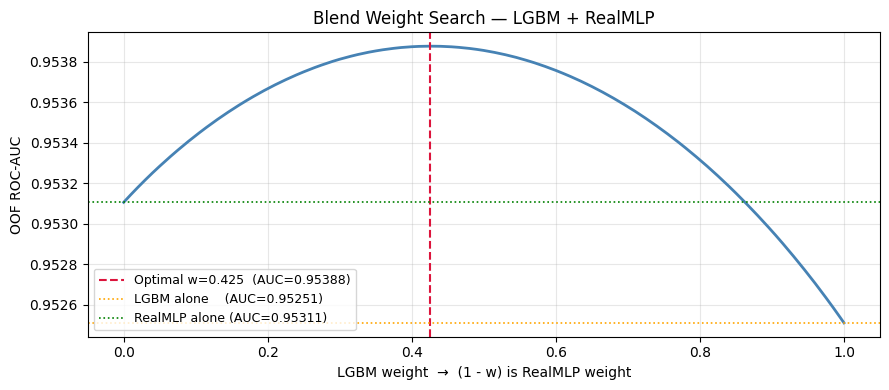

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(weights, aucs, lw=2, color='steelblue')
ax.axvline(best_w, color='crimson', linestyle='--', lw=1.5,
           label=f'Optimal w={best_w:.3f}  (AUC={best_auc:.5f})')
ax.axhline(auc_lgbm,    color='orange', linestyle=':',  lw=1.2,
           label=f'LGBM alone    (AUC={auc_lgbm:.5f})')
ax.axhline(auc_realmlp, color='green',  linestyle=':',  lw=1.2,
           label=f'RealMLP alone (AUC={auc_realmlp:.5f})')
ax.set_xlabel('LGBM weight  →  (1 - w) is RealMLP weight')
ax.set_ylabel('OOF ROC-AUC')
ax.set_title('Blend Weight Search — LGBM + RealMLP')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('blend_curve.png', dpi=120)
plt.show()

## 5. Correlation Check

Lower correlation between OOFs → more diversification benefit from blending.

In [5]:
corr = np.corrcoef(lgbm_oof, realmlp_oof)[0, 1]
print(f"Pearson correlation between OOFs : {corr:.4f}")
print(f"  < 0.98 is good — meaningful diversity between models")
print(f"  < 0.95 is great — expect solid AUC gain from blending")

Pearson correlation between OOFs : 0.9841
  < 0.98 is good — meaningful diversity between models
  < 0.95 is great — expect solid AUC gain from blending


## 6. Apply Optimal Blend to Test + Save

In [6]:
# Apply same optimal weight to test predictions
blended_test = best_w * lgbm_sub + (1 - best_w) * realmlp_sub

# Save blended OOF
oof_blend_df = pd.DataFrame({'id': ids, 'PitNextLap': best_w * lgbm_oof + (1 - best_w) * realmlp_oof})
oof_blend_df.to_csv('oof_blend_lgbm_realmlp.csv', index=False)
print(f"Blended OOF saved : oof_blend_lgbm_realmlp.csv")

# Save submission
test  = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/test.csv')
sub   = pd.DataFrame({'id': test['id'].values, 'PitNextLap': blended_test})
sub.to_csv('submission_blend_lgbm_realmlp.csv', index=False)
print(f"Submission saved  : submission_blend_lgbm_realmlp.csv")
print(sub.head())

print(f"\n── Final Summary ──────────────────────────")
print(f"  LGBM    OOF AUC : {auc_lgbm:.6f}  (weight {best_w:.3f})")
print(f"  RealMLP OOF AUC : {auc_realmlp:.6f}  (weight {1-best_w:.3f})")
print(f"  Blend   OOF AUC : {best_auc:.6f}  (+{best_auc - max(auc_lgbm, auc_realmlp):.6f} vs best single)")

Blended OOF saved : oof_blend_lgbm_realmlp.csv
Submission saved  : submission_blend_lgbm_realmlp.csv
       id  PitNextLap
0  439140    0.005686
1  439141    0.015205
2  439142    0.005310
3  439143    0.293005
4  439144    0.805909

── Final Summary ──────────────────────────
  LGBM    OOF AUC : 0.952511  (weight 0.425)
  RealMLP OOF AUC : 0.953105  (weight 0.575)
  Blend   OOF AUC : 0.953876  (+0.000770 vs best single)
